# Configs

In [1]:
League_Name = "Imaginary_Hammers"

In [2]:
# Seasons
Season_list = [
    "Season_0_2025",
    "Season_m1_2024",
    "Season_m2_2023",
    "Season_m3_2022",
    "Season_m4_2021"
]

In [3]:
#Scoring Categories
Scoring_Categories_Batting = [
    "R",
    "HR",
    "OBP",
    "SLG"
]
Scoring_Categories_Pitching = [
    "K",
    "HR9",
    "ERA",
    "WHIP"
]
Scoring_Categories = Scoring_Categories_Batting + Scoring_Categories_Pitching

In [4]:
import pandas as pd
import os
curr_path = os.path.abspath("/Users/cmartin/Fantasy_Baseball/Ottoneu_Baseball_Projects")
Team_Ranks_df = pd.DataFrame()
for season in Season_list:
    temp_df = pd.read_csv(f"{curr_path}/{League_Name}/{season}/Team_Ranks.csv")
    temp_df['Season'] = season
    Team_Ranks_df = pd.concat([Team_Ranks_df, temp_df], ignore_index=True)
Team_Statistics_df = pd.DataFrame()
for season in Season_list:
    temp_df = pd.read_csv(f"{curr_path}/{League_Name}/{season}/Team_Statistics.csv")
    temp_df['Season'] = season
    Team_Statistics_df = pd.concat([Team_Statistics_df, temp_df], ignore_index=True)

# Historical Final Standings

In [5]:
Team_Ranks_df['Place'] = Team_Ranks_df.groupby('Season')["TOTAL"].rank(method="dense", ascending=False)

In [6]:
Team_Ranks_df.head()

,Team,R,HR,OBP,SLG,K,HR9,ERA,WHIP,TOTAL,CHG,Season,Place
0,St. CGT VI,10.0,9.0,12.0,7.0,11.0,10.0,10.0,11.0,80.0,0.0,Season_0_2025,1.0
1,The Rime of Jamie Moyer,12.0,12.0,10.0,12.0,8.0,6.0,9.0,8.0,77.0,0.0,Season_0_2025,2.0
2,Hornswogglers,11.0,11.0,8.0,10.0,10.0,8.0,7.0,6.0,71.0,1.0,Season_0_2025,3.0
3,Largely Indistinguishables,4.0,1.0,6.0,3.0,12.0,11.0,12.0,12.0,61.0,0.0,Season_0_2025,4.0
4,Carlos Pérez's K-Dance,5.0,7.0,3.0,8.0,4.0,12.0,11.0,10.0,60.0,0.0,Season_0_2025,5.0


In [7]:
Team_Ranks_df['Mean'] = Team_Ranks_df.groupby('Place')['TOTAL'].mean()
Team_Ranks_df['Std'] = Team_Ranks_df.groupby('Place')['TOTAL'].std()

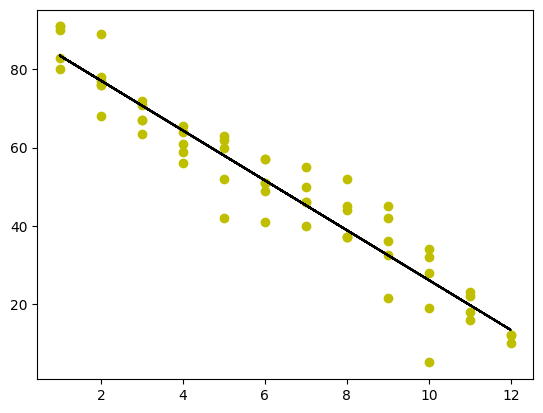

In [8]:
import numpy as np
import matplotlib.pyplot as plt

coef = np.polyfit(Team_Ranks_df['Place'],Team_Ranks_df['TOTAL'],1)
poly1d_fn = np.poly1d(coef) 
# poly1d_fn is now a function which takes in x and returns an estimate for y

plt.plot(Team_Ranks_df['Place'],Team_Ranks_df['TOTAL'], 'yo', Team_Ranks_df['Place'], poly1d_fn(Team_Ranks_df['Place']), '--k')

In [9]:
print(Team_Ranks_df['Place'].unique())
print(poly1d_fn(Team_Ranks_df['Place'].unique()))

[ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12.]
[83.529033   77.14722599 70.76541898 64.38361197 58.00180496 51.61999795
 45.23819094 38.85638393 32.47457692 26.09276991 19.7109629  13.32915589]


In [10]:
Points_Needed = pd.DataFrame({'Place':Team_Ranks_df['Place'].unique(), 'Points_Needed':poly1d_fn(Team_Ranks_df['Place'].unique())})

In [11]:
Points_Needed

,Place,Points_Needed
0,1.0,83.529033
1,2.0,77.147226
2,3.0,70.765419
3,4.0,64.383612
4,5.0,58.001805
5,6.0,51.619998
6,7.0,45.238191
7,8.0,38.856384
8,9.0,32.474577
9,10.0,26.092770


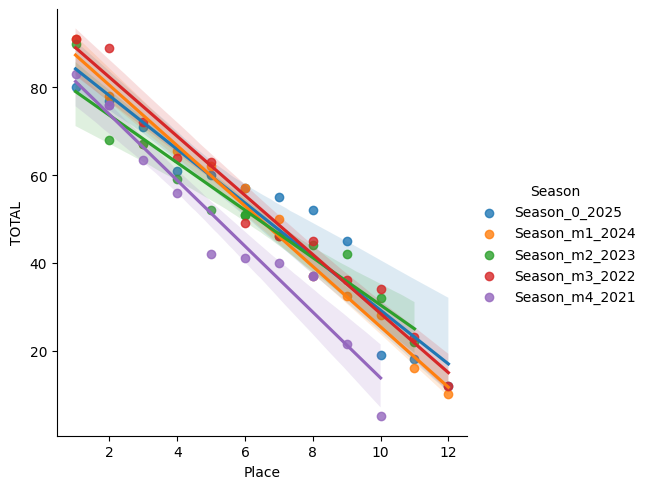

In [12]:
import seaborn as sns
sns.lmplot(data=Team_Ranks_df, x="Place", y="TOTAL", hue='Season')

# Historical Scoring categories

In [13]:
Team_Statistics_df.head()

,TEAM,G,R,HR,OBP,SLG,IP,K,HR9,ERA,WHIP,Season
0,St. CGT VI,1944,1062,306,0.34046,0.43600,1475.2,1632,1.01852,3.45810,1.14660,Season_0_2025
1,The Rime of Jamie Moyer,1889,1118,359,0.33645,0.46971,1499.2,1509,1.12225,3.61880,1.18293,Season_0_2025
2,Hornswogglers,1931,1067,313,0.33533,0.44238,1505.0,1619,1.05847,3.77342,1.21595,Season_0_2025
3,Largely Indistinguishables,1806,942,220,0.32933,0.41728,1500.0,1694,0.90000,2.87400,1.07600,Season_0_2025
4,Carlos Pérez's K-Dance,1765,955,297,0.31807,0.43939,1262.2,1252,0.84820,3.14335,1.16816,Season_0_2025


In [14]:
Team_Statistics_df['Team'] = Team_Statistics_df['TEAM']

In [15]:
Team_Ranks_df.head()

,Team,R,HR,OBP,SLG,K,HR9,ERA,WHIP,TOTAL,CHG,Season,Place,Mean,Std
0,St. CGT VI,10.0,9.0,12.0,7.0,11.0,10.0,10.0,11.0,80.0,0.0,Season_0_2025,1.0,NaN,NaN
1,The Rime of Jamie Moyer,12.0,12.0,10.0,12.0,8.0,6.0,9.0,8.0,77.0,0.0,Season_0_2025,2.0,87.000000,5.147815
2,Hornswogglers,11.0,11.0,8.0,10.0,10.0,8.0,7.0,6.0,71.0,1.0,Season_0_2025,3.0,77.333333,6.742897
3,Largely Indistinguishables,4.0,1.0,6.0,3.0,12.0,11.0,12.0,12.0,61.0,0.0,Season_0_2025,4.0,68.100000,3.435113
4,Carlos Pérez's K-Dance,5.0,7.0,3.0,8.0,4.0,12.0,11.0,10.0,60.0,0.0,Season_0_2025,5.0,61.100000,3.814446


In [16]:
Stat_Ranks = Team_Ranks_df.merge(Team_Statistics_df,on=['Team','Season'],suffixes=['_Pts',''])

In [17]:
Stat_Ranks.columns

Index(['Team', 'R_Pts', 'HR_Pts', 'OBP_Pts', 'SLG_Pts', 'K_Pts', 'HR9_Pts',
       'ERA_Pts', 'WHIP_Pts', 'TOTAL', 'CHG', 'Season', 'Place', 'Mean', 'Std',
       'TEAM', 'G', 'R', 'HR', 'OBP', 'SLG', 'IP', 'K', 'HR9', 'ERA', 'WHIP'],
      dtype='str')

Axes(0.125,0.712609;0.352273x0.167391)
[ 25.28251748 809.36363636]
Axes(0.547727,0.712609;0.352273x0.167391)
[ 11.50840336 202.86204482]
Axes(0.125,0.511739;0.352273x0.167391)
[0.00250328 0.31360785]
Axes(0.547727,0.511739;0.352273x0.167391)
[0.00528697 0.40334252]
Axes(0.125,0.31087;0.352273x0.167391)
[  47.52273265 1138.29011761]
Axes(0.547727,0.31087;0.352273x0.167391)
[-0.02601642  1.26109468]
Axes(0.125,0.11;0.352273x0.167391)
[-0.08937283  4.30970445]
Axes(0.547727,0.11;0.352273x0.167391)
[-0.01743814  1.31090646]


/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_57850/653813371.py:16: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


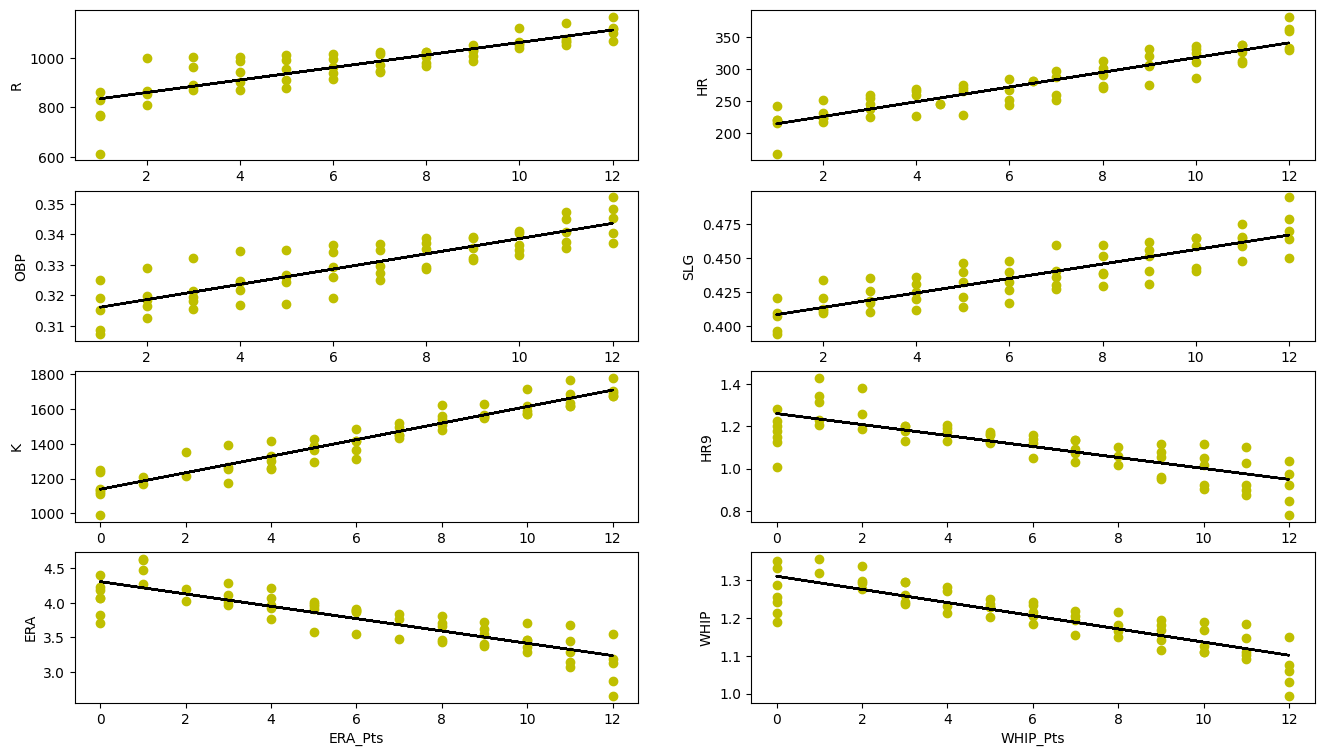

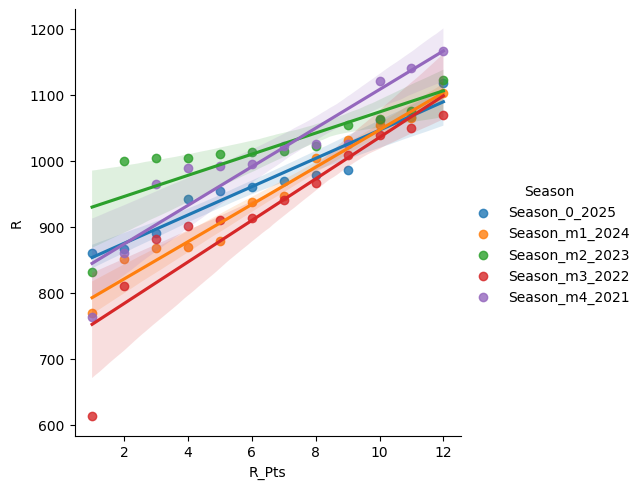

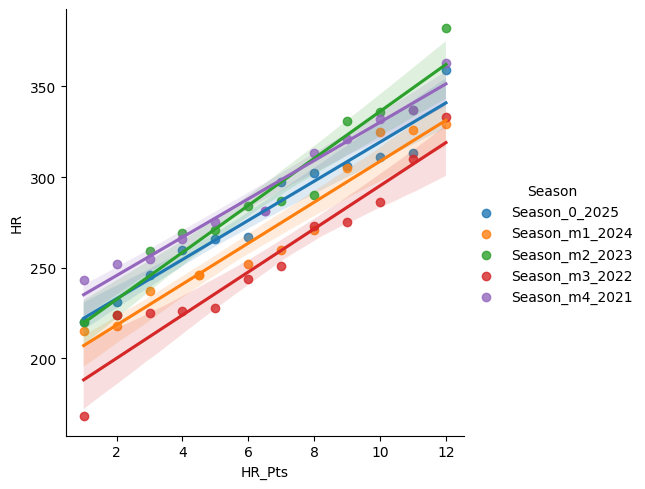

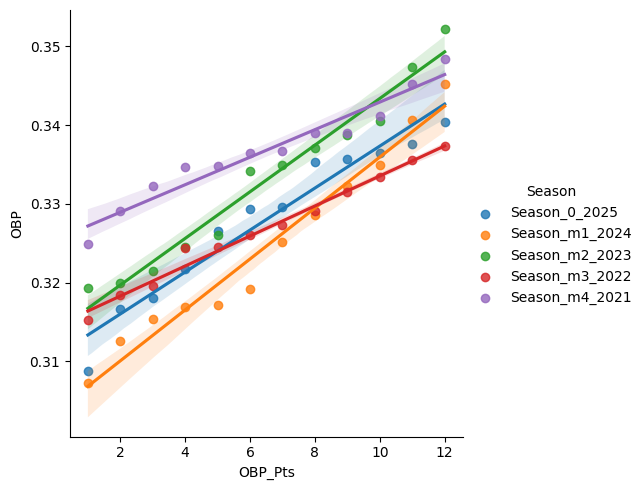

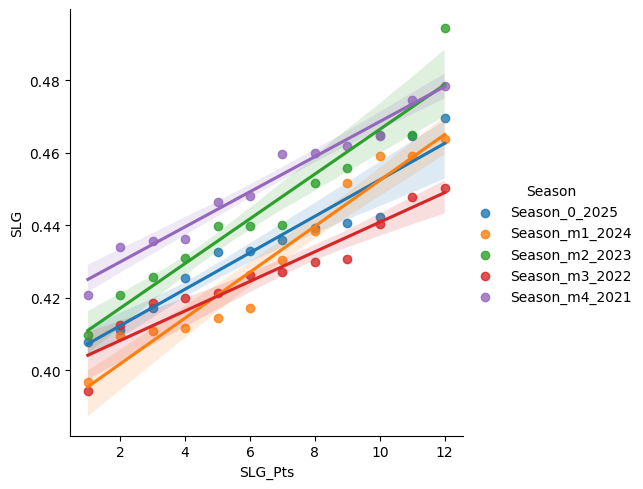

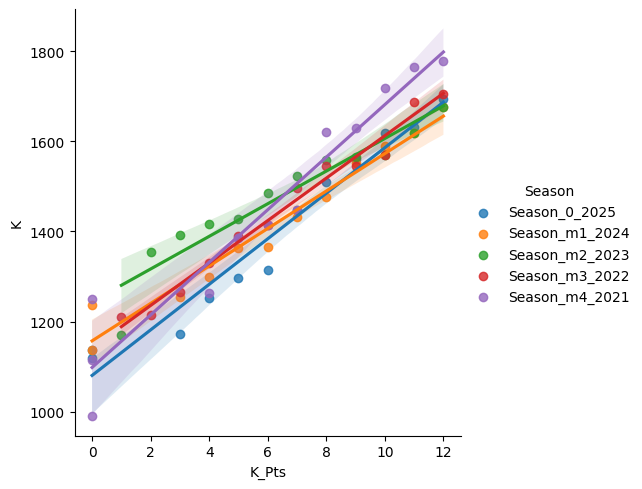

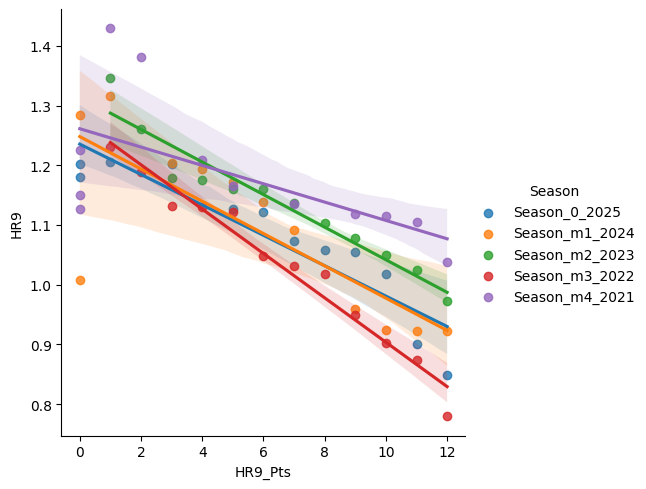

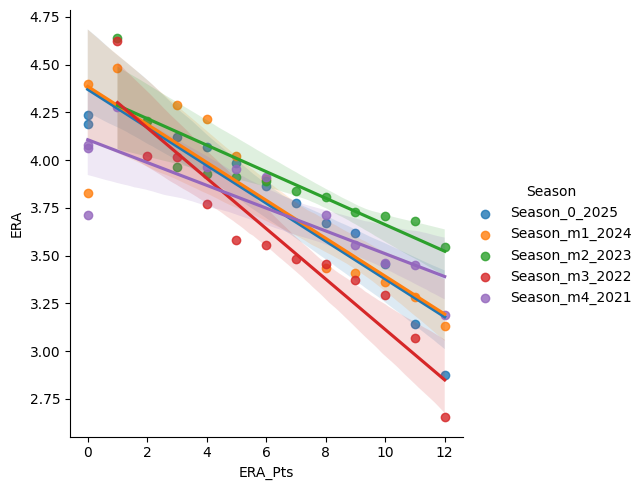

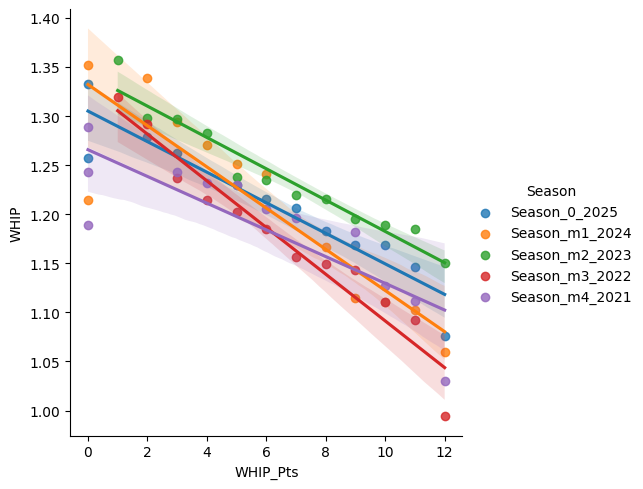

In [52]:
fig, axs = plt.subplots(int(len(Scoring_Categories)/2),2,figsize=(16,9))
SGP_Denom_dict = {}
for stat, this_ax in zip(Scoring_Categories, axs.reshape(-1)):
    print(this_ax)
    coef = np.polyfit(y=Stat_Ranks[stat],x=Stat_Ranks[f'{stat}_Pts'],deg=1)
    print(coef)
    poly1d_fn = np.poly1d(coef)  
    this_ax.plot(Stat_Ranks[f'{stat}_Pts'],Stat_Ranks[stat], 'yo')
    this_ax.set_xlabel(f'{stat}_Pts')
    this_ax.set_ylabel(stat)
    this_ax.plot(Stat_Ranks[f'{stat}_Pts'], poly1d_fn(Stat_Ranks[f'{stat}_Pts']), '--k') 

    sns.lmplot(data=Stat_Ranks, y=stat, x=f'{stat}_Pts', hue='Season')
    SGP_Denom_dict[stat] = coef[0]

fig.show()

In [53]:
print(SGP_Denom_dict)

{'R': np.float64(25.28251748251743), 'HR': np.float64(11.508403361344515), 'OBP': np.float64(0.002503279720279701), 'SLG': np.float64(0.00528697202797202), 'K': np.float64(47.5227326545109), 'HR9': np.float64(-0.026016417074877514), 'ERA': np.float64(-0.08937283374192077), 'WHIP': np.float64(-0.017438135920127117)}


In [56]:
import json
with open(f"{curr_path}/{League_Name}/SGP_Denom_dict.json", 'w') as f:
    json.dump(SGP_Denom_dict, f)